# Chopin Op. 30 No. 2 HMM/DTW Debug Run

This notebook trains one HMM for `Chopin_Op030No2` from a single reference recording and 70% of that piece's recordings, then tests on one held-out recording. The last section compares the HMM-guided online path to an offline DTW path between the same reference/query pair.

In [194]:
from pathlib import Path
import importlib
import numpy as np
import Constants

importlib.reload(Constants)

PIECE_ID = "Chopin_Op030No2"
DATA_DIR = Path("data/wav_22050_mono") / PIECE_ID
TRAIN_FRACTION = 0.70

# The first sorted file is the single reference for this debug model.
recording_paths = sorted(DATA_DIR.glob("*.wav"))
reference_path = recording_paths[0]

rng = np.random.default_rng(207)
query_pool = np.array(recording_paths[1:], dtype=object)
shuffled_pool = query_pool[rng.permutation(len(query_pool))]
train_count = int(np.ceil(TRAIN_FRACTION * len(recording_paths))) - 1
train_paths = sorted(shuffled_pool[:train_count])
heldout_paths = sorted(shuffled_pool[train_count:])
test_path = heldout_paths[0]

print(f"reference: {reference_path.name}")
print(f"total recordings: {len(recording_paths)}")
print(f"training recordings: {1 + len(train_paths)} including the reference ({(1 + len(train_paths)) / len(recording_paths):.1%})")
print(f"held-out recordings: {len(heldout_paths)}")
print(f"test query: {test_path.name}")

reference: Chopin_Op030No2_Ashkenazy-1981_pid9058-19.wav
total recordings: 34
training recordings: 24 including the reference (70.6%)
held-out recordings: 10
test query: Chopin_Op030No2_Chiu-1999_pid9048-19.wav


## Train One Debug HMM

In [195]:
import IterativeTrainHMM
importlib.reload(IterativeTrainHMM)

A, Pi, Means, Covars = IterativeTrainHMM.Exec_IterativeTrainHMM(
    str(reference_path),
    [str(path) for path in train_paths],
)

print(f"transition matrix: {A.shape}")
print(f"initial distribution: {Pi.shape}")
print(f"emission states: {len(Means)}")
print(f"feature dim: {Means[0].shape[0]}")

transition matrix: (2990, 2990)
initial distribution: (2990,)
emission states: 2990
feature dim: 12


## Load Reference And Held-Out Query

In [196]:
import librosa

import Constants

reference_audio, sample_rate = librosa.load(reference_path, sr=Constants.DEFAULT_SAMPLE_RATE)
query_audio, _ = librosa.load(test_path, sr=Constants.DEFAULT_SAMPLE_RATE)

reference_chroma = librosa.feature.chroma_stft(
    y=reference_audio,
    sr=sample_rate,
    hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
)
query_chroma = librosa.feature.chroma_stft(
    y=query_audio,
    sr=sample_rate,
    hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
)

print(f"reference chroma: {reference_chroma.shape}")
print(f"query chroma: {query_chroma.shape}")

reference chroma: (12, 2990)
query chroma: (12, 3951)


## Offline DTW Baseline

In [201]:
_, offline_warping_path = librosa.sequence.dtw(
    X=reference_chroma,
    Y=query_chroma,
    backtrack=True,
)
offline_path = offline_warping_path[::-1]

def path_to_query_reference_series(path, query_frame_count):
    series = np.full(query_frame_count, np.nan)
    for query_index in range(query_frame_count):
        matching_ref_frames = path[path[:, 1] == query_index, 0]
        if len(matching_ref_frames):
            series[query_index] = np.median(matching_ref_frames)

    valid = np.flatnonzero(~np.isnan(series))
    if len(valid) == 0:
        raise ValueError("DTW path did not cover any query frames")

    missing = np.flatnonzero(np.isnan(series))
    if len(missing):
        series[missing] = np.interp(missing, valid, series[valid])
    return series

offline_reference_by_query = path_to_query_reference_series(offline_path, query_chroma.shape[1])
print(f"offline DTW path points: {len(offline_path)}")

offline DTW path points: 4332


## Online Alignment Tests

In [ ]:
import HMMOLTW
importlib.reload(HMMOLTW)
from scipy.special import logsumexp

SEARCH_HALF_WIDTH = 250
VITERBI_GLOBAL_HALF_WIDTH = 750
HMM_STREAMING_DTW_WEIGHT = .6

def run_standard_oltw(reference_chroma, query_chroma, search_half_width=SEARCH_HALF_WIDTH):
    """Pure online DTW through the project OLTW recurrence, using librosa chroma features."""
    oltw_state = HMMOLTW.InitializeStreamingDTW(reference_chroma.shape[1])
    dummy_viterbi_log_probs = np.zeros(reference_chroma.shape[1])
    dummy_viterbi_log_probs[0] = 1

    estimates = []
    for query_index in range(query_chroma.shape[1]):
        oltw_state = HMMOLTW.StepStreamingDTW(
            oltw_state,
            reference_chroma,
            query_chroma[:, query_index],
            dummy_viterbi_log_probs,
            search_half_width,
            HMMWeight=0,
        )
        estimates.append(oltw_state.CurrentReferenceEstimate)

    return np.array(estimates)

def global_constraint_center(query_index, query_frame_count, state_count):
    if query_frame_count <= 1:
        return 0
    progress = query_index / (query_frame_count - 1)
    return int(round(progress * (state_count - 1)))

def step_viterbi_global_constraint(running_state, hmm, observation, center, half_width):
    state_count = hmm.StateCount
    window_start = max(0, center - half_width)
    window_end = min(state_count, center + half_width + 1)
    active_states = np.arange(window_start, window_end)

    previous_active_states = np.flatnonzero(np.isfinite(running_state.NormalizedLogProbabilities))
    if len(previous_active_states) == 0:
        previous_active_states = np.array([max(0, min(center, state_count - 1))])

    log_emissions = np.array([
        HMMOLTW.ComputeLogGaussianEmission(
            observation,
            hmm.Means[state_index],
            hmm.CovarianceInverses[state_index],
            hmm.LogCovarianceDeterminants[state_index],
        )
        for state_index in active_states
    ])

    previous_log_probs = running_state.NormalizedLogProbabilities[previous_active_states]
    transition_log_probs = hmm.LogTransitionMatrix[np.ix_(previous_active_states, active_states)]
    best_predecessor_log_probs = (previous_log_probs[:, np.newaxis] + transition_log_probs).max(axis=0)
    raw_active_log_probs = Constants.LAMBDA * log_emissions + best_predecessor_log_probs

    constrained_log_probs = np.full(state_count, -np.inf)
    normalizer = logsumexp(raw_active_log_probs)
    if np.isfinite(normalizer):
        constrained_log_probs[active_states] = raw_active_log_probs - normalizer
    else:
        constrained_log_probs[active_states] = -np.log(len(active_states))

    return HMMOLTW.ViterbiRunningState(NormalizedLogProbabilities=constrained_log_probs)

def run_online_viterbi_global_constraint(
    reference_chroma,
    query_chroma,
    transition_matrix,
    initial_distribution,
    means,
    covars,
    global_half_width=VITERBI_GLOBAL_HALF_WIDTH,
):
    hmm = HMMOLTW.PreprocessHMMParameters(
        transition_matrix,
        means,
        covars,
    )
    viterbi_state = HMMOLTW.InitializeViterbi(initial_distribution)

    estimates = []
    query_frame_count = query_chroma.shape[1]
    for query_index in range(query_frame_count):
        center = global_constraint_center(query_index, query_frame_count, hmm.StateCount)
        viterbi_state = step_viterbi_global_constraint(
            viterbi_state,
            hmm,
            query_chroma[:, query_index],
            center,
            global_half_width,
        )
        estimates.append(int(np.argmax(viterbi_state.NormalizedLogProbabilities)))

    return np.array(estimates)


def run_hmm_influenced_streaming_dtw(
    reference_chroma,
    query_chroma,
    transition_matrix,
    initial_distribution,
    means,
    covars,
    search_half_width=SEARCH_HALF_WIDTH,
    hmm_weight=HMM_STREAMING_DTW_WEIGHT,
):
    hmm, viterbi_state, streaming_dtw_state = HMMOLTW.InitializeHMMStreamingDTW(
        reference_chroma,
        transition_matrix,
        initial_distribution,
        means,
        covars,
        SearchHalfWidth=search_half_width,
        HMMWeight=hmm_weight,
    )

    estimates = []
    for query_index in range(query_chroma.shape[1]):
        estimate, viterbi_state, streaming_dtw_state = HMMOLTW.ProcessNextFrame(
            viterbi_state,
            streaming_dtw_state,
            hmm,
            reference_chroma,
            query_chroma[:, query_index],
            search_half_width,
            hmm_weight,
        )
        estimates.append(estimate)

    return np.array(estimates)

standard_oltw_reference_by_query = run_standard_oltw(
    reference_chroma,
    query_chroma,
    search_half_width=SEARCH_HALF_WIDTH,
)

viterbi_reference_by_query = run_online_viterbi_global_constraint(
    reference_chroma,
    query_chroma,
    A,
    Pi,
    Means,
    Covars,
    global_half_width=SEARCH_HALF_WIDTH,
)

hmm_streaming_dtw_reference_by_query = run_hmm_influenced_streaming_dtw(
    reference_chroma,
    query_chroma,
    A,
    Pi,
    Means,
    Covars,
    search_half_width=SEARCH_HALF_WIDTH,
    hmm_weight=HMM_STREAMING_DTW_WEIGHT,
)

standard_error_frames = standard_oltw_reference_by_query - offline_reference_by_query
viterbi_error_frames = viterbi_reference_by_query - offline_reference_by_query
hmm_streaming_dtw_error_frames = hmm_streaming_dtw_reference_by_query - offline_reference_by_query

standard_error_seconds = standard_error_frames * Constants.DEFAULT_HOP_SIZE_SAMPLES / sample_rate
viterbi_error_seconds = viterbi_error_frames * Constants.DEFAULT_HOP_SIZE_SAMPLES / sample_rate
hmm_streaming_dtw_error_seconds = hmm_streaming_dtw_error_frames * Constants.DEFAULT_HOP_SIZE_SAMPLES / sample_rate

def summarize_error(label, error_frames, error_seconds):
    print(label)
    print(f"  mean absolute error: {np.mean(np.abs(error_frames)):.2f} frames / {np.mean(np.abs(error_seconds)):.3f} s")
    print(f"  median absolute error: {np.median(np.abs(error_frames)):.2f} frames / {np.median(np.abs(error_seconds)):.3f} s")
    print(f"  95th percentile absolute error: {np.percentile(np.abs(error_frames), 95):.2f} frames / {np.percentile(np.abs(error_seconds), 95):.3f} s")

summarize_error("Standard OLTW vs offline librosa DTW", standard_error_frames, standard_error_seconds)
summarize_error("Globally constrained online Viterbi vs offline librosa DTW", viterbi_error_frames, viterbi_error_seconds)
summarize_error("HMM-influenced streaming DTW vs offline librosa DTW", hmm_streaming_dtw_error_frames, hmm_streaming_dtw_error_seconds)

Standard OLTW vs offline librosa DTW
  mean absolute error: 10.79 frames / 0.251 s
  median absolute error: 2.00 frames / 0.046 s
  95th percentile absolute error: 58.00 frames / 1.347 s
Globally constrained online Viterbi vs offline librosa DTW
  mean absolute error: 97.36 frames / 2.261 s
  median absolute error: 7.00 frames / 0.163 s
  95th percentile absolute error: 366.00 frames / 8.499 s
HMM-influenced streaming DTW vs offline librosa DTW
  mean absolute error: 14.70 frames / 0.341 s
  median absolute error: 4.00 frames / 0.093 s
  95th percentile absolute error: 66.00 frames / 1.533 s


## Error Plots Against Offline DTW

The first figure shows each online estimate minus the offline `librosa.sequence.dtw` reference position. Both errors are shown in seconds of reference-recording time.

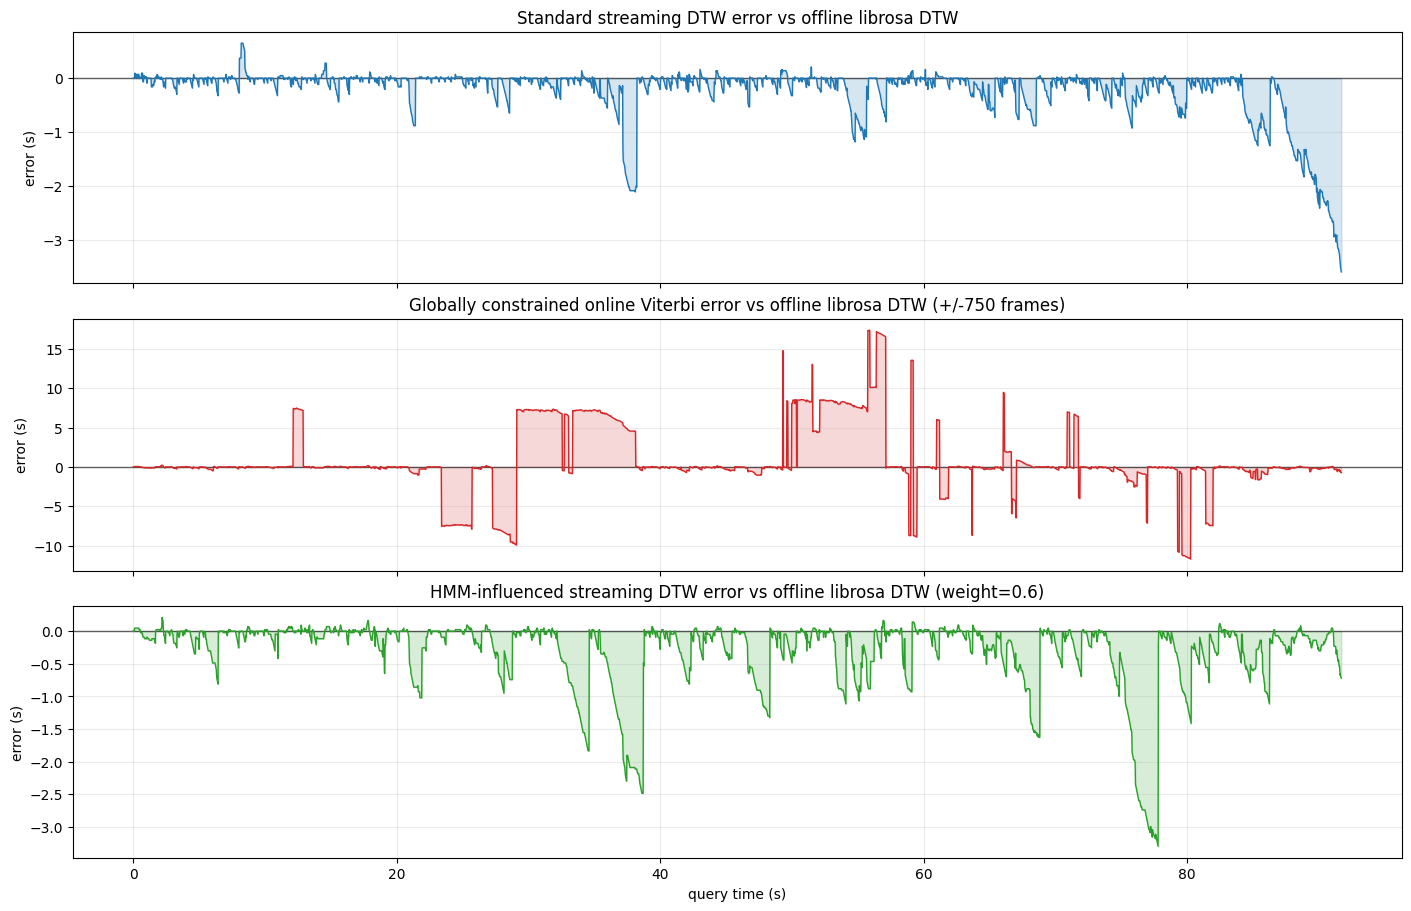

In [203]:
import matplotlib.pyplot as plt

query_time = librosa.frames_to_time(
    np.arange(query_chroma.shape[1]),
    sr=sample_rate,
    hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True, constrained_layout=True)

axes[0].axhline(0, color="black", linewidth=1, alpha=0.6)
axes[0].plot(query_time, standard_error_seconds, color="tab:blue", linewidth=1)
axes[0].fill_between(query_time, 0, standard_error_seconds, color="tab:blue", alpha=0.18)
axes[0].set_ylabel("error (s)")
axes[0].set_title("Standard streaming DTW error vs offline librosa DTW")
axes[0].grid(alpha=0.25)

axes[1].axhline(0, color="black", linewidth=1, alpha=0.6)
axes[1].plot(query_time, viterbi_error_seconds, color="tab:red", linewidth=1)
axes[1].fill_between(query_time, 0, viterbi_error_seconds, color="tab:red", alpha=0.18)
axes[1].set_ylabel("error (s)")
axes[1].set_title(f"Globally constrained online Viterbi error vs offline librosa DTW (+/-{VITERBI_GLOBAL_HALF_WIDTH} frames)")
axes[1].grid(alpha=0.25)

axes[2].axhline(0, color="black", linewidth=1, alpha=0.6)
axes[2].plot(query_time, hmm_streaming_dtw_error_seconds, color="tab:green", linewidth=1)
axes[2].fill_between(query_time, 0, hmm_streaming_dtw_error_seconds, color="tab:green", alpha=0.18)
axes[2].set_xlabel("query time (s)")
axes[2].set_ylabel("error (s)")
axes[2].set_title(f"HMM-influenced streaming DTW error vs offline librosa DTW (weight={HMM_STREAMING_DTW_WEIGHT})")
axes[2].grid(alpha=0.25)

plt.show()

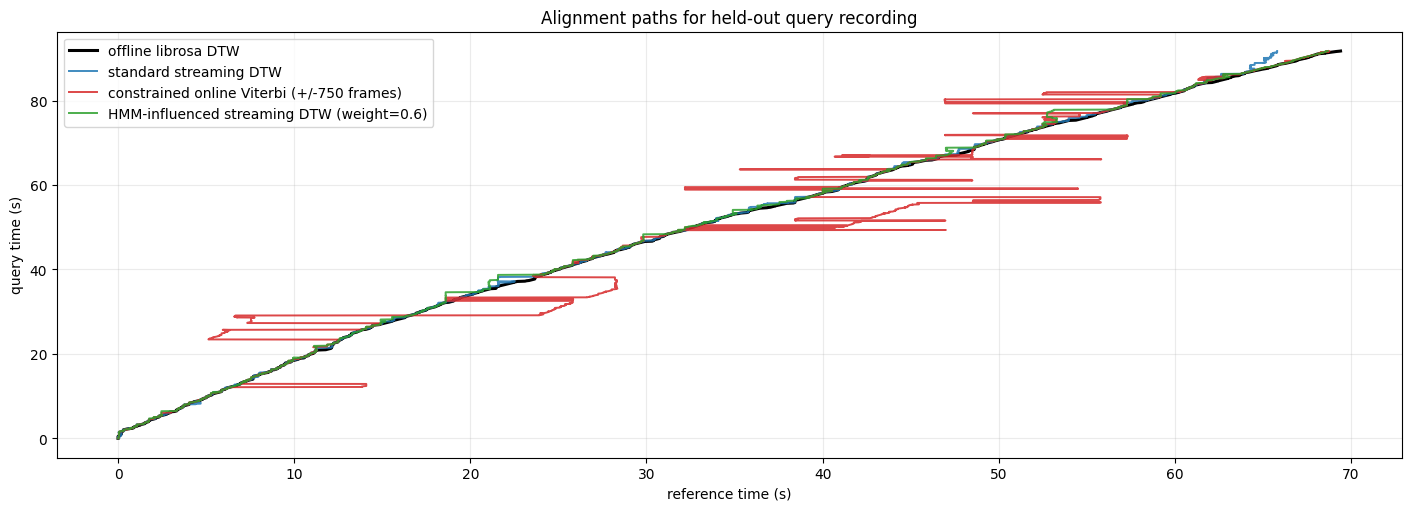

In [204]:
reference_time_offline = librosa.frames_to_time(
    offline_reference_by_query,
    sr=sample_rate,
    hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
)
reference_time_standard = librosa.frames_to_time(
    standard_oltw_reference_by_query,
    sr=sample_rate,
    hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
)
reference_time_viterbi = librosa.frames_to_time(
    viterbi_reference_by_query,
    sr=sample_rate,
    hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
)
reference_time_hmm_streaming_dtw = librosa.frames_to_time(
    hmm_streaming_dtw_reference_by_query,
    sr=sample_rate,
    hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
)

fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)
ax.plot(reference_time_offline, query_time, label="offline librosa DTW", linewidth=2.2, color="black")
ax.plot(reference_time_standard, query_time, label="standard streaming DTW", linewidth=1.4, alpha=0.85, color="tab:blue")
ax.plot(reference_time_viterbi, query_time, label=f"constrained online Viterbi (+/-{VITERBI_GLOBAL_HALF_WIDTH} frames)", linewidth=1.4, alpha=0.85, color="tab:red")
ax.plot(reference_time_hmm_streaming_dtw, query_time, label=f"HMM-influenced streaming DTW (weight={HMM_STREAMING_DTW_WEIGHT})", linewidth=1.4, alpha=0.85, color="tab:green")
ax.set_ylabel("query time (s)")
ax.set_xlabel("reference time (s)")
ax.set_title("Alignment paths for held-out query recording")
ax.legend()
ax.grid(alpha=0.25)
plt.show()